In [1]:
import pandas as pd
import numpy as np

# Setting seed for consistency
np.random.seed(44)

n_orders = 15000
hubs = ['Seattle_SEA1', 'San_Jose_SJC2', 'Austin_AUS5', 'New_York_JFK8', 'Chicago_ORD3']

data = pd.DataFrame({
    'order_id': range(1001, 1001 + n_orders),
    'hub': np.random.choice(hubs, size=n_orders),
    'distance_miles': np.random.uniform(5, 50, size=n_orders), # Last-mile distance
    'priority': np.random.choice(['Standard', 'Express', 'Same-Day'], size=n_orders, p=[0.6, 0.3, 0.1])
})

# Simulating delivery hours (Base time + distance factor + random noise)
# We'll bake in a "bottleneck" in New_York_JFK8
data['planned_hours'] = 4 + (data['distance_miles'] * 0.1)
data['actual_hours'] = data['planned_hours'] * np.where(data['hub'] == 'New_York_JFK8', 
                                                       np.random.uniform(1.2, 1.8, n_orders), # The Bottleneck
                                                       np.random.uniform(0.9, 1.1, n_orders))

# Creating the Target Metric: Delay
data['delay_hours'] = (data['actual_hours'] - data['planned_hours']).clip(lower=0)
data['is_delayed'] = data['delay_hours'] > 0.5 # Delayed if more than 30 mins late

print(data.head())

   order_id            hub  distance_miles  priority  planned_hours  \
0      1001   Chicago_ORD3       11.945834   Express       5.194583   
1      1002  New_York_JFK8       43.662955  Same-Day       8.366296   
2      1003  San_Jose_SJC2        7.255593   Express       4.725559   
3      1004  New_York_JFK8       28.367518  Standard       6.836752   
4      1005  New_York_JFK8       21.290479  Standard       6.129048   

   actual_hours  delay_hours  is_delayed  
0      5.295494     0.100911       False  
1     11.414943     3.048648        True  
2      4.581706     0.000000       False  
3     10.169337     3.332585        True  
4      9.700618     3.571570        True  


In [2]:
# Defining Cost Logic
# Standard: $15/hr delay, Express/Same-Day: $25/hr delay (refunds + support)
data['recovery_cost'] = np.where(
    data['priority'] == 'Standard',
    data['delay_hours'] * 15,
    data['delay_hours'] * 25
)

# Aggregating by Hub
hub_analysis = data.groupby('hub').agg({
    'is_delayed': 'mean',
    'delay_hours': 'mean',
    'recovery_cost': 'sum'
}).rename(columns={'is_delayed': 'delay_rate'}).sort_values('recovery_cost', ascending=False)

print(hub_analysis)

               delay_rate  delay_hours  recovery_cost
hub                                                  
New_York_JFK8    1.000000     3.381617  192199.038374
Austin_AUS5      0.102254     0.166156    9750.704140
Chicago_ORD3     0.115711     0.166257    9734.309794
Seattle_SEA1     0.120120     0.169935    9675.485302
San_Jose_SJC2    0.124914     0.170274    9359.940486


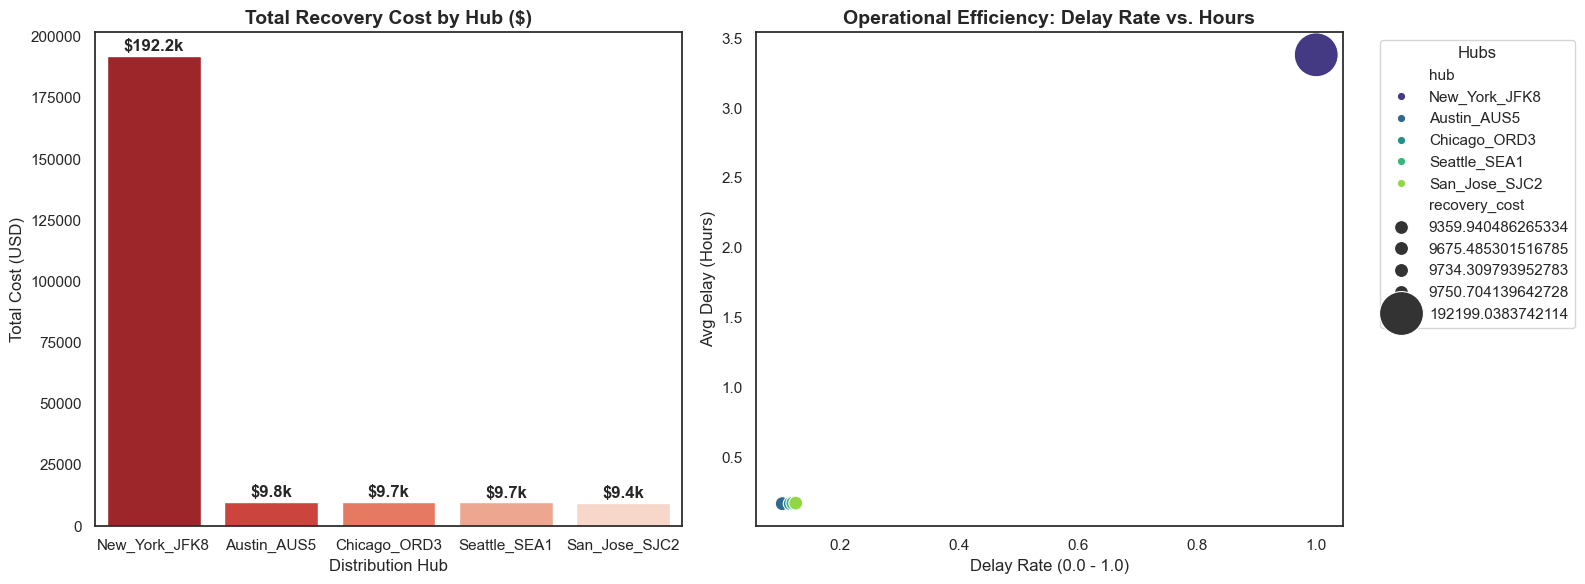

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting professional theme
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Financial Impact (Fixed Code) ---
sns.barplot(
    ax=axes[0], 
    x=hub_analysis.index, 
    y='recovery_cost', 
    data=hub_analysis, 
    palette='Reds_r',
    hue=hub_analysis.index, 
    legend=False            
)
axes[0].set_title('Total Recovery Cost by Hub ($)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cost (USD)')
axes[0].set_xlabel('Distribution Hub')

# Add labels on top of bars
for i, v in enumerate(hub_analysis['recovery_cost']):
    axes[0].text(i, v + 2000, f'${v/1000:.1f}k', ha='center', fontweight='bold')

# --- Plot 2: Delay Rate vs Avg Delay  ---
sns.scatterplot(
    ax=axes[1], 
    x='delay_rate', 
    y='delay_hours', 
    size='recovery_cost', 
    hue=hub_analysis.index, 
    data=hub_analysis, 
    sizes=(100, 1000), 
    palette='viridis'
)
axes[1].set_title('Operational Efficiency: Delay Rate vs. Hours', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Delay (Hours)')
axes[1].set_xlabel('Delay Rate (0.0 - 1.0)')
axes[1].legend(title='Hubs', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()